<a href="https://colab.research.google.com/github/Priyan437/Machine-Learning/blob/main/Credit_Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

priyanshukumarthak_credit_path = kagglehub.dataset_download('priyanshukumarthak/credit')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/credit/creditcard.csv


In [ ]:
data = pd.read_csv('/kaggle/input/credit/creditcard.csv')
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
data.shape

(284807, 31)

In [ ]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
data.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
data.isnull().sum().max()

0

In [ ]:
print('Not Fraud data rows is :',(data[data['Class'] == 0]['Class'].count()/data['Class'].count()*100))
print('Fraud data rows is :',(data[data['Class'] == 1]['Class'].count()/data['Class'].count()*100))

Not Fraud data rows is : 99.82725143693798
Fraud data rows is : 0.1727485630620034


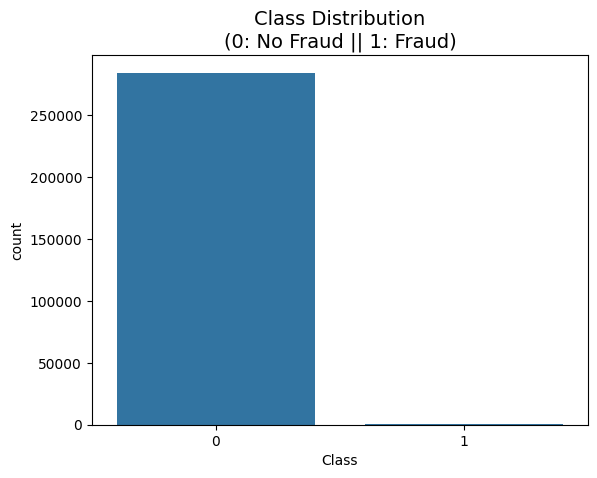

In [ ]:
sns.countplot(x='Class', data=data)
plt.title('Class Distribution\n(0: No Fraud || 1: Fraud)', fontsize=14)
plt.show()


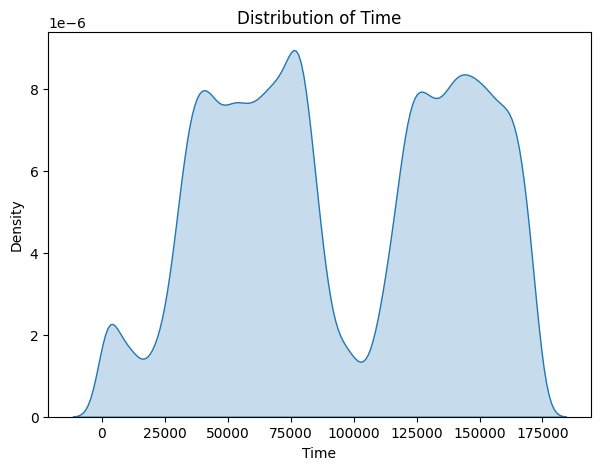

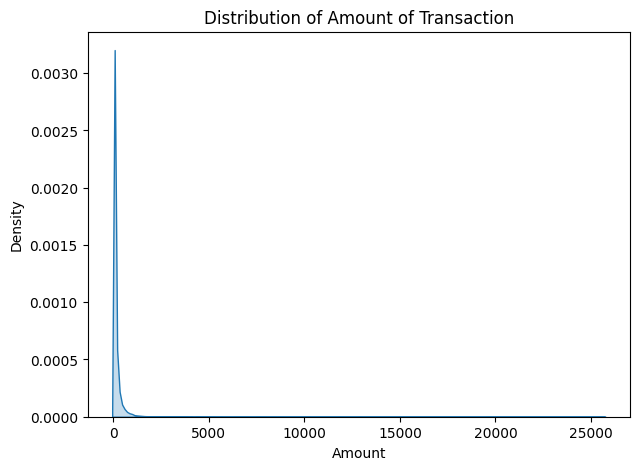

In [ ]:
plt.figure(figsize=(7, 5))
sns.kdeplot(data=data, x='Time', fill=True)
plt.title('Distribution of Time')
plt.show()

plt.figure(figsize=(7, 5))
sns.kdeplot(data=data, x='Amount', fill=True)
plt.title('Distribution of Amount of Transaction')
plt.show()


In [ ]:
print(f"Total No of Fraud cases in the given dataset is {data[data['Class'] == 1]['Class'].count()}")

Total No of Fraud cases in the given dataset is 492


In [ ]:
## Most of the columns are scaled so we need to apply scaling on two columns 'Time' and 'Amount'

from sklearn.preprocessing import StandardScaler, RobustScaler

std_scaler = StandardScaler()
ro_scaler = RobustScaler()

data['Scaled_Time'] = ro_scaler.fit_transform(data['Time'].values.reshape(-1,1))
data['Scaled_Amount'] = ro_scaler.fit_transform(data['Amount'].values.reshape(-1,1))

data.drop(['Time','Amount'], axis = 1 ,inplace = True)

In [ ]:
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Scaled_Time,Scaled_Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,-0.994983,1.783274
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.994983,-0.269825
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,-0.994972,4.983721
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,-0.994972,1.418291
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.994960,0.670579


In [ ]:
scaled_time = data['Scaled_Time']
scaled_amount = data['Scaled_Amount']

data.drop(['Scaled_Amount','Scaled_Time'],axis = 1,inplace = True)
data.insert(0,'scaled_time',scaled_time)
data.insert(0,'scaled_amount',scaled_amount)

data.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import StratifiedKFold


print(f"No Frauds Percentage is {(data[data['Class'] == 0]['Class'].count())/data['Class'].count()* 100}")
print(f"Frauds Percentage is {(data[data['Class'] == 1]['Class'].count())/data['Class'].count()* 100}")

x = data.drop('Class',axis = 1)
y = data['Class']

sss = StratifiedKFold(n_splits = 5, shuffle = False)

for train_index,test_index in sss.split(x,y):
    print("train:",train_index,"test:",test_index)
    original_xtrain,original_xtest = x.iloc[train_index],x.iloc[test_index]
    original_ytrain,original_ytest = y.iloc[train_index],y.iloc[test_index]


original_xtrain = original_xtrain.values
original_xtest = original_xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

test_unique_value, test_count_value = np.unique(original_ytest,return_counts = True)
train_unique_value, train_count_value = np.unique(original_ytrain,return_counts = True)
print("--"*50)

print("The distribution of data in the stratified folds is : \n")
print("For test data :",test_count_value/len(original_ytest),"\n")
print("For train data :",train_count_value/len(original_ytrain))

No Frauds Percentage is 99.82725143693798
Frauds Percentage is 0.1727485630620034
train: [ 30473  30496  31002 ... 284804 284805 284806] test: [    0     1     2 ... 57017 57018 57019]
train: [     0      1      2 ... 284804 284805 284806] test: [ 30473  30496  31002 ... 113964 113965 113966]
train: [     0      1      2 ... 284804 284805 284806] test: [ 81609  82400  83053 ... 170946 170947 170948]
train: [     0      1      2 ... 284804 284805 284806] test: [150654 150660 150661 ... 227866 227867 227868]
train: [     0      1      2 ... 227866 227867 227868] test: [212516 212644 213092 ... 284804 284805 284806]
----------------------------------------------------------------------------------------------------
The distribution of data in the stratified folds is : 

For test data : [0.99827952 0.00172048] 

For train data : [0.99827076 0.00172924]


In [ ]:
data = data.sample(frac = 1)

fraud_data = data.loc[data['Class'] == 1]
non_fraud_data = data.loc[data['Class'] == 0][:492]

normal_distributed_data = pd.concat([fraud_data,non_fraud_data])
ndata = normal_distributed_data.sample(frac = 1,random_state = 42)

ndata.shape

(984, 31)

In [ ]:
!git config user.name

Priyan437


In [ ]:
!git init

Reinitialized existing Git repository in /kaggle/working/.git/


In [ ]:
!git config --global user.email "hopestolive678@gmail.com"
!git config --global user.name "Priyan437"

In [ ]:
!git remote add origin https://github.com/Priyan437/Machine-Learning.git

error: remote origin already exists.


In [ ]:
!git remote -v

origin	https://github.com/Priyan437/Machine-Learning.git (fetch)
origin	https://github.com/Priyan437/Machine-Learning.git (push)


In [ ]:
!git add .

In [ ]:
!git commit -m "Credit Risk Basic Model"

[master 4f01221] Credit Risk Basic Model
 1 file changed, 1 insertion(+), 1 deletion(-)


In [ ]:
!git push -u origin master

Username for 'https://github.com': 